# MNIST Digit Classifier with PyTorch (CNN)

In [ ]:
# Install required packages
%pip install torch
%pip install torchvision
%pip install numpy
%pip install matplotlib

In [3]:
# Import required packages
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
# Parameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Data Pipeline
# transform converts images to PyTorch tensors and normalizes pixel values to [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Model Architecture
class DigitClassifierCNN(nn.Module):
    def __init__(self):
        super(DigitClassifierCNN, self).__init__()
        # First convolutional layer: input channels = 1 (grayscale), output channels = 16, kernel size = 3x3
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second convolutional layer: input channels = 16, output channels = 32, kernel size = 3x3
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # 7x7 is the size after two pooling layers (28/2/2)
        self.fc2 = nn.Linear(128, 10) # 10 output classes for digits 0-9

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten for the fully connected layer
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [7]:
# Initialize model
model = DigitClassifierCNN().to(DEVICE)

In [8]:
# Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [9]:
# Traning Loop
print("Starting training...") # Visualize user what is happening
for epoch in range(EPOCHS):
    model.train() # Set model to training mode
    running_loss = 0.0
    for img, label in train_loader:
        img, label = img.to(DEVICE), label.to(DEVICE)

        optimizer.zero_grad()   # Clear old gradiants
        outputs = model(img)      # Forward pass
        loss = criterion(outputs, label) # Calculate loss
        loss.backward()         # Backward pass
        optimizer.step()        # Update weights

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}")

Starting training...
Epoch [1/5], Loss: 0.1773
Epoch [2/5], Loss: 0.0486
Epoch [3/5], Loss: 0.0351
Epoch [4/5], Loss: 0.0266
Epoch [5/5], Loss: 0.0198


In [10]:
# Evaluation
model.eval() # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # No need to calculate gradients during evaluation
    for img, label in test_loader:
        img, label = img.to(DEVICE), label.to(DEVICE)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability
        total += label.size(0)
        correct += (predicted == label).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 99.08%


In [11]:
# Export the trained model
import torch

print("Exporting model...") # Visualize user what is happening
torch.save(model.state_dict(), "../src/models/pytorch_cnn.pth")

Exporting model...


# MNIST Digit Classifier with Scikit-Learn (Random Forest)

In [ ]:
# Install required packages
%pip install scikit-learn
%pip install pandas
%pip install seaborn
%pip install joblib

In [13]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [7]:
# Data Pipeline
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto') # fetch dataset from OpenML
X, y = mnist.data, mnist.target # split into features and labels

# Preprocessing
X = X / 255.0 # normalize pixel values to [0,1]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Model Architecture
# initialize Random Forest model with 100 trees and use all available cores for parallel processing
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [9]:
# Model Training
print("Starting training...") # Visualize user what is happening
rf_model.fit(X_train, y_train)

Starting training...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Evaluating model...
Test Accuracy: 96.75%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.96      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



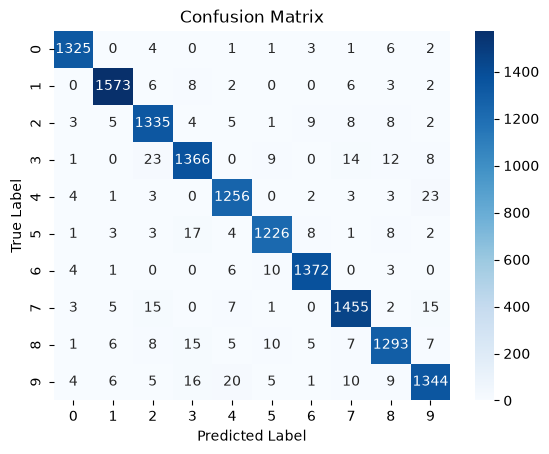

In [14]:
# Evaluation
print("Evaluating model...") # Visualize user what is happening
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

# classification_report provides precision, recall, f1-score for each digits
print("Classification Report:\n", classification_report(y_test, y_pred))

# create heatmap with confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [47]:
# Export the trained model
import joblib

print("Exporting model...") # Visualize user what is happening
joblib.dump(rf_model, "../src/models/sklearn_rf.joblib")

Exporting model...


['../src/models/sklearn_rf.joblib']

# MNIST Digit Classifier with TensorFlow/Keras (CNN)

Mirror implementation of PyTorch model in TensorFlow/Keras

In [ ]:
# Install required packages
%pip install tensorflow

In [26]:
# If you want DirectML support, choose this instead
%pip install tensorflow-directml

In [12]:
# Import required packages
import tensorflow as tf
from tensorflow.keras import layers, models

In [13]:
# Parameters
BATCH_SIZE = 64
EPOCHS = 5

In [14]:
# Data Pipeline
# load built-in MNIST dataset from Keras datasets module
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocessing
# normalize pixel values to [0,1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Add 1 channel dimension (grayscale) to the images for CNN input (CNN expects 4 input: batch_size, height, width, channels)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]


In [15]:
# Model Architecture
def build_digit_classifier_model():
    model = models.Sequential([
        # First convolutional layer
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        # Second convolutional layer
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)), 

        # Flatten the output for the fully connected layer
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        
        # Output layer: 10 classes (digits 0-9)
        layers.Dense(10)
    ])
    
    
    return model

In [16]:
# Initialize model
model_tfcnn = build_digit_classifier_model()

c:\Users\aiju2\Documents\Projects\Simple Classifier\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Loss Function & Optimizer
# SparseCategoricalCrossentropy is used for multi-class classification problems where labels are provided as integers rather than one-hot encoded vectors. The 'from_logits=True' argument indicates that the output of the model is not normalized (i.e., it is raw logits).
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model_tfcnn.compile(optimizer='adam',
                    loss=loss_fn, 
                    metrics=['accuracy'])

In [18]:
# Model Training
print("Starting training...") # Visualize user what is happening
model_tfcnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1)

Starting training...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9344 - loss: 0.2188 - val_accuracy: 0.9832 - val_loss: 0.0592
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9806 - loss: 0.0619 - val_accuracy: 0.9842 - val_loss: 0.0496
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9870 - loss: 0.0427 - val_accuracy: 0.9868 - val_loss: 0.0394
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9897 - loss: 0.0336 - val_accuracy: 0.9885 - val_loss: 0.0391
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9917 - val_loss: 0.0340


In [19]:
# Evaluation
print("Evaluating model...") # Visualize user what is happening
test_loss, test_accuracy = model_tfcnn.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Evaluating model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9898 - loss: 0.0324
Test Accuracy: 98.98%


In [21]:
# Export the trained model
import tensorflow as tf

print("Exporting model...") # Visualize user what is happening
model_tfcnn.save("../src/models/tensorflow_cnn.keras")

Exporting model...


# Multi-Agent Ensemble Classifier (Scikit-Learn)

In [33]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [34]:
# Data Pipeline
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto') # fetch dataset from OpenML
X, y = mnist.data, mnist.target # split into features and labels

# Preprocessing
# MLP classifier are highly sensitive to unscaled data.
X = X / 255.0

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify ensures that the class distribution is preserved in both training and testing sets

In [35]:
# Model A: Multi-layer Perceptron (MLP) Classifier
# a feedforward network with one hidden layer of 128 neurons.
print("Initializing MLP Classifier...")
agent_mlp = MLPClassifier(hidden_layer_sizes=(128,), 
                          max_iter=300,
                          alpha=1e-4,       # L2 penalty (regularization)
                          solver='adam',    # optimization algorithm  
                          random_state=42)


Initializing MLP Classifier...


In [36]:
# Model B: Distance-Based Classifier (KNN)
# looks 5 closest images in the training set and predict the label
print("Initializing KNN Classifier...")
agent_knn = KNeighborsClassifier(n_neighbors=5,
                                 weights='distance', 
                                 n_jobs=-1) # n_jobs=-1 uses all available CPU cores for parallel processing


Initializing KNN Classifier...


In [37]:
# Model C: Tree-Based Classifier (Random Forest)
# reuse the baseline model
print("Initializing Random Forest Classifier...")
agent_rf = RandomForestClassifier(n_estimators=100, 
                                  random_state=42, 
                                  n_jobs=-1)


Initializing Random Forest Classifier...


In [38]:
# Create multi-agent ensemble
# voting='soft' means it averages the probability from all the agents
print("Building Multi-Agent Voting Ensemble...")
ensemble_model = VotingClassifier(
    estimators=[
        ('Multi-Layer_Perceptron', agent_mlp),
        ('K_Nearest_Neighbors', agent_knn),
        ('Random_Forest', agent_rf)
    ],
    voting='soft'
)

Building Multi-Agent Voting Ensemble...


In [39]:
# Model Training
print("Starting training...")
ensemble_model.fit(X_train, y_train)

Starting training...


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('Multi-Layer_Perceptron', ...), ('K_Nearest_Neighbors', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[MLPClassifier...ndom_state=42), KNeighborsCla...ts='distance'), RandomForestC...ndom_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,784


Evaluating model...
Test Accuracy: 98.33%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.98      0.99      0.99      1575
           2       0.99      0.98      0.98      1398
           3       0.99      0.98      0.98      1428
           4       0.99      0.98      0.98      1365
           5       0.98      0.98      0.98      1263
           6       0.99      0.99      0.99      1375
           7       0.98      0.98      0.98      1459
           8       0.99      0.97      0.98      1365
           9       0.97      0.98      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



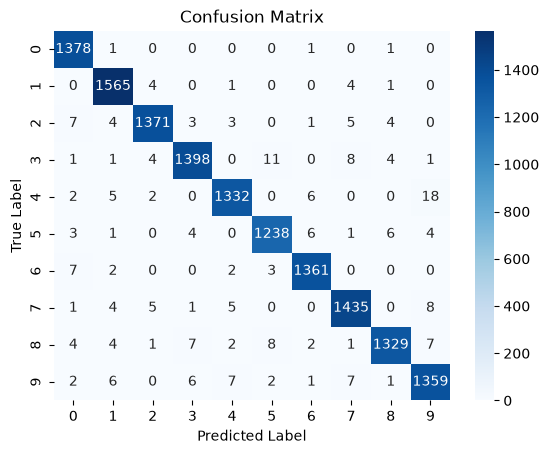

In [40]:
# Evaluation
print("Evaluating model...")
y_pred = ensemble_model.predict(X_test)

# Calculate accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# classification_report provides precision, recall, f1-score for each digits
print("Classification Report:\n", classification_report(y_test, y_pred))

# create heatmap with confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [42]:
# Export the trained model
import joblib

print("Exporting model...") # Visualize user what is happening
joblib.dump(ensemble_model, "../src/models/sklearn_ensemble.joblib")

Exporting model...


['../src/models/sklearn_ensemble.joblib']

# Upload Models to Hugging Face

In [ ]:
%pip install huggingface_hub

In [45]:
# Import required packages
from huggingface_hub import HfApi

In [46]:
# Initialize Hugging Face API
api = HfApi()
repo_id = "akinoshi/mnist-framework-backoff"

In [48]:
# Upload the trained model
print("Uploading model to Hugging Face Hub...") # Visualize user what is happening

uploads = [
    ("../src/models/sklearn_rf.joblib", "sklearn_rf.joblib"),
    ("../src/models/sklearn_ensemble.joblib", "sklearn_ensemble.joblib"),
    ("../src/models/pytorch_cnn.pth", "pytorch_cnn.pth"),
    ("../src/models/tensorflow_cnn.keras", "tensorflow_cnn.keras"),
]

for local_path, repo_path in uploads:
    try:
        print(f"Uploading {repo_path} to {repo_id}...")
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_path,
            repo_id=repo_id,
            repo_type="model"
        )
        print(f"Uploaded {repo_path} successfully.")
    except Exception as error:
        print(f"Error uploading {repo_path}: {error}")

print("Model upload completed successfully!")


Uploading model to Hugging Face Hub...
Uploading sklearn_rf.joblib to akinoshi/mnist-framework-backoff...


Processing Files (1 / 1): 100%|██████████|  136MB /  136MB, 11.8MB/s  
New Data Upload: 100%|██████████| 82.4MB / 82.4MB, 7.28MB/s  


Uploaded sklearn_rf.joblib successfully.
Uploading sklearn_ensemble.joblib to akinoshi/mnist-framework-backoff...


Processing Files (1 / 1): 100%|██████████|  490MB /  490MB, 39.5MB/s  
New Data Upload: 100%|██████████|  490MB /  490MB, 39.5MB/s  


Uploaded sklearn_ensemble.joblib successfully.
Uploading pytorch_cnn.pth to akinoshi/mnist-framework-backoff...


Processing Files (1 / 1): 100%|██████████|  831kB /  831kB, 80.0kB/s  
New Data Upload: 100%|██████████|  831kB /  831kB, 80.0kB/s  


Uploaded pytorch_cnn.pth successfully.
Uploading tensorflow_cnn.keras to akinoshi/mnist-framework-backoff...


Processing Files (1 / 1): 100%|██████████| 1.34MB / 1.34MB,  129kB/s  
New Data Upload: 100%|██████████| 1.34MB / 1.34MB,  129kB/s  


Uploaded tensorflow_cnn.keras successfully.
Model upload completed successfully!
